In [4]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt

In [2]:
!wget https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/course_lead_scoring_2026.csv


--2026-10-06 01:52:08--  https://raw.githubusercontent.com/DataTalksClub/machine-learning-zoomcamp/main/cohorts/2026/data/course_lead_scoring_2026.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.108.133, 185.199.109.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 278746 (272K) [text/plain]
Saving to: ‘course_lead_scoring_2026.csv’

course_lead_scoring 100%[===================>] 272.21K  --.-KB/s    in 0.02s   

2026-10-06 01:52:08 (13.7 MB/s) - ‘course_lead_scoring_2026.csv’ saved [278746/278746]



In [5]:
df = pd.read_csv('course_lead_scoring_2026.csv')
df.head()

,lead_source,industry,employment_status,location,annual_income,number_of_courses_viewed,interaction_count,lead_score,converted
0,organic_search,technology,employed,europe,88160.0,3,4,0.64,1
1,social_media,technology,employed,south_america,72688.0,3,7,0.72,1
2,referral,retail,employed,europe,44697.0,3,4,0.58,1
3,paid_ads,manufacturing,student,NaN,NaN,3,6,0.57,0
4,referral,manufacturing,student,north_america,24062.0,4,5,0.62,1


In [10]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

str_columns = list(df.dtypes[df.dtypes == 'str'].index)

for c in str_columns:
    df[c] = df[c].str.lower().str.replace(' ', '_')

In [12]:
df.isna().sum()

lead_source                 148
industry                    240
employment_status           194
location                    208
annual_income               369
number_of_courses_viewed      0
interaction_count             0
lead_score                   35
converted                     0
dtype: int64

In [14]:
df['interaction_count'].value_counts()

interaction_count
4     800
5     798
6     653
3     644
2     492
7     476
1     325
0     283
8     259
9     146
10     82
11     31
12      8
13      3
Name: count, dtype: int64

In [19]:
categorical_features = ['lead_source','industry','employment_status','location']
df[categorical_features] = df[categorical_features].fillna('NA')

In [20]:
df[categorical_features].isna().sum()

lead_source          0
industry             0
employment_status    0
location             0
dtype: int64

In [21]:
numerical_features = ['lead_score','interaction_count','number_of_courses_viewed','annual_income']
df[numerical_features] = df[numerical_features].fillna(0)

In [18]:
df.groupby('industry').size()

industry
NA                240
education         639
finance           720
healthcare        840
manufacturing     463
retail            925
technology       1173
dtype: int64

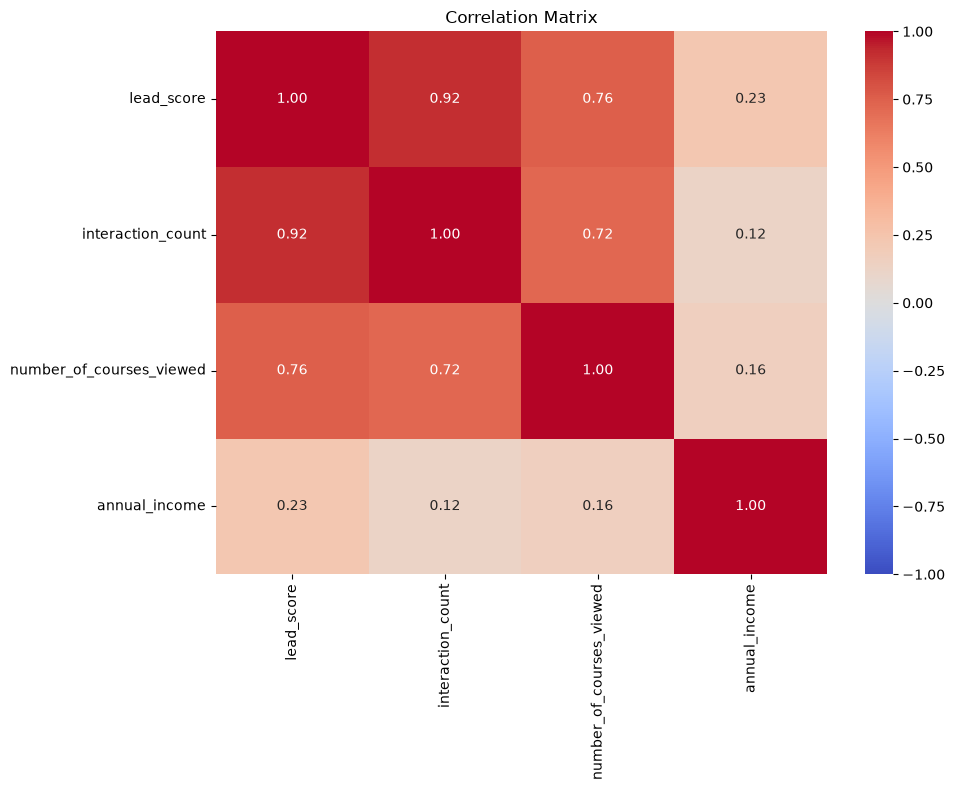

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 8))
sns.heatmap(
    df[numerical_features].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0
)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [32]:
from sklearn.model_selection import train_test_split
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=42)
df_train, df_val = train_test_split(
    df_full_train, test_size=0.25, random_state=42
)

In [33]:
from sklearn.metrics import mutual_info_score

In [34]:
def mutual_info_churn_score(series):
    return mutual_info_score(series, df_full_train.converted)

In [35]:
mi = df_full_train[categorical_features].apply(mutual_info_churn_score)
mi.sort_values(ascending = False)

lead_source          0.034761
employment_status    0.020313
industry             0.002898
location             0.001050
dtype: float64

In [37]:
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

features = [
    col for col in categorical_features + numerical_features
    if col != 'converted'
]

# Dense output avoids the sparse-index compatibility issue
dv = DictVectorizer(sparse=False)

X_train = dv.fit_transform(df_train[features].to_dict(orient='records'))
X_val = dv.transform(df_val[features].to_dict(orient='records'))

y_train = df_train['converted']
y_val = df_val['converted']

model = LogisticRegression(
    solver='liblinear',
    C=1.0,
    max_iter=1000,
    random_state=42
)
model.fit(X_train, y_train)

y_pred = model.predict(X_val)
print(f"Validation accuracy: {accuracy_score(y_val, y_pred):.2f}")

Validation accuracy: 0.65


In [46]:
features

['lead_source',
 'industry',
 'employment_status',
 'location',
 'lead_score',
 'interaction_count',
 'number_of_courses_viewed',
 'annual_income']